# Lead Scoring — RF, HGB, XGBoost & LightGBM Hyperparameter Search

**Primary KPI** : `composite = AUC_test × 100 + decile_gap_pp`  (higher = better)

| Metric | What it measures |
|---|---|
| `AUC` | rank-ordering quality (0–1 → 0–100 after scaling) |
| `decile_gap_pp` | D10 SE − D1 SE (percentage points, 0–100) |
| `composite` | AUC×100 + gap_pp — single number to maximise |

**Models** : Random Forest, HistGradientBoosting, XGBoost, LightGBM

**Sections** : Config → Data → Features → Split → Eval utils → Sweep (RF, HGB, XGB, LGB) → Leaderboard → Deep-dive → Correlation → Comparison

## 1 · Config & Imports

In [33]:
import re, time, warnings
from itertools import product as iterproduct

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.tree import export_text

import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")

## 1b · Pipeline Config

In [34]:
# ══════════════════════════════════════════════════════════════
# PIPELINE CONFIG — single source of truth
# ══════════════════════════════════════════════════════════════

# ── Paths ──
DATA_PATH          = "../reports/test_scored.h5"
OPS_PATH           = "../reports/partner_ops_train_vector.csv"
COORDS_PATH        = "../reports/partner_coordinates.csv"
TRAIN_DATA_PATH    = "../artifacts/train_data.h5"

# ── Target ──
TARGET             = "installed_decision"

# ── Sweep ──
N_RANDOM_SAMPLES   = 120       # random combos per model type
TEST_SIZE          = 0.30
RANDOM_STATE       = 42
FILL_VALUE         = -999

# ── Temporal windows (auto-detected from ops CSV in §3, or override) ──
# TEMPORAL_WINDOWS will be populated after loading ops data.
# If you want to force specific windows, uncomment:
# TEMPORAL_WINDOWS = [30, 60, 365]

# ── Static ops columns (non-temporal, always included) ──
STATIC_OPS_COLS = [
    "queue_velocity", "plan_created_rate", "active_tickets",
    "nmbr_active_leads", "expected_daily_slots", "has_shock",
]

# ── Collinearity threshold ──
COLLINEAR_THRESHOLD = 0.7

# ── Plot theme ──
plt.rcParams.update({
    "figure.facecolor": "#0a0e17",
    "axes.facecolor":   "#111827",
    "axes.edgecolor":   "#1e293b",
    "axes.labelcolor":  "#9ca3af",
    "xtick.color":      "#6b7280",
    "ytick.color":      "#6b7280",
    "text.color":       "#e2e8f0",
    "grid.color":       "#1e293b",
    "font.family":      "monospace",
    "font.size":        10,
})

PALETTE = dict(
    amber="#f0b429", blue="#60a5fa", green="#10b981", red="#ef4444",
    purple="#a78bfa", cyan="#22d3ee", pink="#f472b6", gray="#4a5568",
)
AMBER, BLUE, GREEN, RED = PALETTE["amber"], PALETTE["blue"], PALETTE["green"], PALETTE["red"]
PURPLE, CYAN, PINK, GRAY = PALETTE["purple"], PALETTE["cyan"], PALETTE["pink"], PALETTE["gray"]


## 2 · Feature Registry

All features are defined **once** in `FEATURE_FAMILIES`.  
Temporal variants are generated automatically via `_temporal()` — adding a
new window means changing only `TEMPORAL_WINDOWS`.

**New**: `partner_geo` family — derived from DynamoDB partner coordinates
(`n_clusters`, `dist_to_partner_center_m`).

In [35]:
# ══════════════════════════════════════════════════════════════
# FEATURE FAMILIES — single source of truth
# ══════════════════════════════════════════════════════════════

def _temporal(names):
    """Return list of '{name}_{wd}d' for each name × window."""
    return [f"{n}_{wd}d" for wd in TEMPORAL_WINDOWS for n in names]


FEATURE_FAMILIES = {
    "spatial": {
        "base": [
            "predicted_field_hex",
            "predicted_field_hex_all_wmean",
            "predicted_field_hex_all_kswmean",
            "predicted_field_hex_all_min",
            "predicted_field_hex_all_max",
            "predicted_field_hex_all_std",
            "n_overlapping_hexes_field",
            "total_sources_all_hexes",
            "contested_field",
            "field_momentum",
        ],
        "temporal": ["predicted_field_hex"],
    },
    "hex": {
        "base": [
            "parent_se", "parent_total", "parent_color_numeric",
            "n_covering_partners", "parent_overlap", "install_velocity",
            "se_momentum",
        ],
        "temporal": ["weighted_se"],
        "temporal_suffix": "shrunk",
    },
    "hop": {
        "base": [
            "hop1_se_wmean", "hop2_se_wmean", "hop3_se_wmean",
            "hop1_se_std",   "hop2_se_std",   "hop3_se_std",
            "hop1_count",    "hop2_count",    "hop3_count",
            "se_gradient_1to3", "se_confirmed", "isolation_ratio",
        ],
        "temporal": [
            "hop1_se", "hop2_se", "hop3_se",
            "se_gradient_1to3", "se_confirmed",
        ],
        "temporal_suffix_map": {
            "hop1_se": "wmean", "hop2_se": "wmean", "hop3_se": "wmean",
        },
    },
    "contested": {
        "base": [
            "contested_area_km2", "contested_radius_m",
            "contested_se", "n_overlapping_partners",
        ],
        "temporal": ["contested_se"],
    },
    "boundary": {
        "base": [
            "dist_to_boundary_edge_point_hex",
            "dist_to_cluster_center_point_hex",
            "depth_score_point_hex",
            "mean_dist_to_edge_m", "mean_dist_to_center_m",
            "total_area_boundaries", "nmbr_overlap_clusters",
            "nearest_boundary_dist_m", "nmbr_boundaries_within_100m",
            "worst_depth_score", "any_near_edge", "is_solo_cluster",
        ],
    },
    "geometry": {
        "base": [
            "local_anisotropy", "local_density", "hull_area",
            "linearity_score", "spread_m",
            "dense_score", "gully_score", "sparse_score",
        ],
        "temporal": [
            "local_density", "dense_score", "sparse_score", "spread_m",
        ],
    },
    "lead": {
        "base": ["hard_density", "density_regime", "min_dist"],
    },
    "partner_geo": {
        "base": [
            "n_clusters",
            "partner_centroids_25m",
            "partner_centroids_50m",
            "partner_centroids_100m",
            "partner_centroids_200m",
            "nearest_centroid_dist_m",
        ],
    },
    "active_bookings": {
        "base": [
            "active_bookings_0_50m",
            "active_bookings_50_100m",
            "active_bookings_100_200m",
            "has_active_booking_0_50m",
            "has_active_booking_50_100m",
            "has_active_booking_100_200m",
        ],
    },
    "temporal_calendar": {
        "base": [
            "day_of_week",
            "is_weekend",
        ],
    },
    "active_users": {
        "base": [
            "active_users_0_50m",
            "active_users_50_100m",
            "active_users_100_200m",
            "has_active_user_0_50m",
            "has_active_user_50_100m",
            "has_active_user_100_200m",
        ],
    },
    "data_consumption": {
        "base": [
            "data_gb_0_50m",
            "data_gb_50_100m",
            "data_gb_100_200m",
            "data_points_0_50m",
            "data_points_50_100m",
            "data_points_100_200m",
            "has_data_usage_0_50m",
            "has_data_usage_50_100m",
            "has_data_usage_100_200m",
        ],
    },
    # ops family is populated dynamically after data load
}


def build_feature_list(families, ops_cols=None):
    """
    Expand FEATURE_FAMILIES into a flat list + family_map.

    Returns
    -------
    features : list[str]
    family_map : dict[str, str]   (feature_name → family_name)
    """
    features, family_map = [], {}

    for fam_name, spec in families.items():
        fam_feats = list(spec.get("base", []))

        # expand temporal features
        default_suffix = spec.get("temporal_suffix", None)
        suffix_map = spec.get("temporal_suffix_map", {})

        for name in spec.get("temporal", []):
            for wd in TEMPORAL_WINDOWS:
                sfx = suffix_map.get(name, default_suffix)
                col = f"{name}_{wd}d"
                if sfx:
                    col = f"{col}_{sfx}"
                fam_feats.append(col)

        for f in fam_feats:
            features.append(f)
            family_map[f] = fam_name

    # ops (dynamic)
    if ops_cols:
        for f in ops_cols:
            features.append(f)
            family_map[f] = "ops"

    return features, family_map

print("Feature families defined:",
      ", ".join(f"{k}({len(v.get('base',[]))}+{len(v.get('temporal',[]))}t)"
                for k, v in FEATURE_FAMILIES.items()))




Feature families defined: spatial(10+1t), hex(7+1t), hop(12+5t), contested(4+1t), boundary(12+0t), geometry(8+4t), lead(3+0t), partner_geo(6+0t), active_bookings(6+0t), temporal_calendar(2+0t), active_users(6+0t), data_consumption(9+0t)


## 3 · Data Load & Ops Merge

In [36]:
# ── Load scored leads ──
df = pd.read_hdf(DATA_PATH, "df")
print(f"Shape before ops merge: {df.shape}")

# ── Load ops (train-window only — leak-free) ──
df_ops_train = pd.read_csv(OPS_PATH)
print(f"Ops train: {df_ops_train.shape}")

# ── Auto-detect temporal windows from ops CSV ──
TEMPORAL_WINDOWS = sorted([
    int(c.replace("se_", "").replace("d", ""))
    for c in df_ops_train.columns
    if re.match(r"^se_\d+d$", c) and "delta" not in c
])
print(f"Temporal windows detected: {TEMPORAL_WINDOWS}")

Shape before ops merge: (18082, 204)
Ops train: (1475, 43)
Temporal windows detected: [30, 60, 365]


In [37]:
# ── Build ops column list dynamically from TEMPORAL_WINDOWS ──
smallest_wd = min(TEMPORAL_WINDOWS)

# Temporal ops metrics per window
OPS_TEMPORAL_METRICS = ["se", "decline_rate", "median_response_min"]
OPS_DELTA_METRICS    = ["se_delta", "decline_rate_delta", "response_delta"]

rf_ops_cols = ["partner_id"]
for wd in TEMPORAL_WINDOWS:
    rf_ops_cols += [f"{m}_{wd}d" for m in OPS_TEMPORAL_METRICS]
    if wd != smallest_wd:
        rf_ops_cols += [f"{m}_{smallest_wd}_{wd}" for m in OPS_DELTA_METRICS]

rf_ops_cols += STATIC_OPS_COLS
rf_ops_cols = [c for c in rf_ops_cols if c in df_ops_train.columns]

# ── Merge ──
df["partner_id"] = df["partner_id"].astype(str)
df_ops_train["partner_id"] = df_ops_train["partner_id"].astype(str)
df = df.merge(df_ops_train[rf_ops_cols], on="partner_id", how="left", suffixes=("", "_ops"))
df = df.loc[:, ~df.columns.str.endswith("_ops")]
print(f"Shape after ops merge: {df.shape}")

_ops_feature_cols = [c for c in rf_ops_cols if c != "partner_id"]
print(f"Ops columns merged: {len(_ops_feature_cols)}")

Shape after ops merge: (18082, 223)
Ops columns merged: 19


### 3b · Partner Coordinates Merge

Loads partner cluster centroids from the coordinates CSV (separate from ops).
Uses **BallTree** on each partner's centroids to compute per-lead radius features:

- `n_clusters` — total hex clusters the partner operates
- `partner_centroids_25m / 50m / 100m / 200m` — how many centroids fall within each radius of the lead
- `nearest_centroid_dist_m` — distance to the closest centroid

These capture whether the lead sits in the core vs fringe of a partner's territory.


In [38]:
import json as _json
from sklearn.neighbors import BallTree as _BallTree

CENTROID_RADII_M = [25, 50, 100, 200]
EARTH_R = 6_371_000  # metres

# ── Load coordinates (separate artifact, not in ops vector) ──
import os
if os.path.exists(COORDS_PATH):
    df_coords_raw = pd.read_csv(COORDS_PATH)
    print(f"Partner coordinates loaded: {df_coords_raw.shape}")

    # ── Parse JSON → per-partner list of centroid arrays ──
    _partner_centroids = {}   # partner_id → np.array([[lat_rad, lon_rad], ...])
    _partner_n_clusters = {}

    for _, row in df_coords_raw.iterrows():
        pid = str(row["partner_id"])
        raw = row.get("coordinates", None)

        if pd.isna(raw) or not raw:
            _partner_n_clusters[pid] = 0
            continue
        try:
            clusters = _json.loads(raw) if isinstance(raw, str) else raw
            centroids = [c["centroid"] for c in clusters
                         if "centroid" in c and c["centroid"] and c["centroid"][0] is not None]
            if centroids:
                _partner_centroids[pid] = np.radians(np.array(centroids, dtype=float))
                _partner_n_clusters[pid] = len(centroids)
            else:
                _partner_n_clusters[pid] = 0
        except Exception:
            _partner_n_clusters[pid] = 0

    print(f"  Partners with centroids: {len(_partner_centroids)}")
    print(f"  Median clusters/partner: {np.median(list(_partner_n_clusters.values())):.0f}")

    # ── Pre-build a BallTree per partner (only for partners with ≥1 centroid) ──
    _partner_trees = {}
    for pid, coords_rad in _partner_centroids.items():
        if len(coords_rad) >= 1:
            _partner_trees[pid] = _BallTree(coords_rad, metric="haversine")

    # ── Compute per-lead features ──
    df["partner_id"] = df["partner_id"].astype(str)
    lead_coords_rad = np.radians(df[["latitude", "longitude"]].values)

    n_clusters_arr = np.zeros(len(df), dtype=int)
    nearest_dist_arr = np.full(len(df), np.nan)
    radius_counts = {r: np.zeros(len(df), dtype=int) for r in CENTROID_RADII_M}

    for idx in range(len(df)):
        pid = df["partner_id"].iloc[idx]
        n_clusters_arr[idx] = _partner_n_clusters.get(pid, 0)

        tree = _partner_trees.get(pid)
        if tree is None:
            continue

        pt = lead_coords_rad[idx].reshape(1, -1)

        # Nearest centroid
        dist_rad, _ = tree.query(pt, k=1)
        nearest_dist_arr[idx] = dist_rad[0, 0] * EARTH_R

        # Radius counts
        for r_m in CENTROID_RADII_M:
            r_rad = r_m / EARTH_R
            count = tree.query_radius(pt, r=r_rad, count_only=True)[0]
            radius_counts[r_m][idx] = count

    # ── Assign to df ──
    df["n_clusters"] = n_clusters_arr
    df["nearest_centroid_dist_m"] = nearest_dist_arr
    for r_m in CENTROID_RADII_M:
        df[f"partner_centroids_{r_m}m"] = radius_counts[r_m]

    # ── Report ──
    print(f"\n  Feature summary:")
    print(f"    n_clusters         — median: {df['n_clusters'].median():.0f}, max: {df['n_clusters'].max():.0f}")
    print(f"    nearest_centroid   — median: {df['nearest_centroid_dist_m'].median():.0f}m, "
          f"p90: {df['nearest_centroid_dist_m'].quantile(0.9):.0f}m")
    for r_m in CENTROID_RADII_M:
        col = f"partner_centroids_{r_m}m"
        n_pos = (df[col] > 0).sum()
        print(f"    {col:25s} — leads with ≥1: {n_pos:,} ({n_pos/len(df)*100:.1f}%), "
              f"mean: {df[col].mean():.2f}")
else:
    print(f"WARNING: {COORDS_PATH} not found — partner_geo features will be NaN")
    df["n_clusters"] = np.nan
    df["nearest_centroid_dist_m"] = np.nan
    for r_m in CENTROID_RADII_M:
        df[f"partner_centroids_{r_m}m"] = np.nan

print(f"\nShape after coordinates merge: {df.shape}")



Shape after coordinates merge: (18082, 229)


### 3c · Active Bookings in Vicinity (Leak-Free)

Source: **train_data.h5** — the full lead lifecycle from the training SQL query
(`query_lead_tasks.txt`), covering ALL decision types (installed, declined,
indeterminate, hanging).

A lead is **active at `t0`** if:
```
first_notified_time ≤ t0  AND  (terminal_time > t0  OR  terminal_time IS NaT)
```
HANGING leads have `terminal_time = NaT` → always active (no terminal event).

**Mutually exclusive rings:** 0–50 m, 50–100 m, 100–200 m.
Each ring gets a **count** + **boolean** feature.

**No leakage:**
- Source is TRAIN data (materialised query), target is TEST data.
- Never touches `installed_decision`.
- `active_at_t0` is observable system state.
- Excludes self by `mobile`.

In [39]:
# ── Load train leads (from query_lead_tasks SQL, all decision types) ──
import os
if not os.path.exists(TRAIN_DATA_PATH):
    raise FileNotFoundError(f"{TRAIN_DATA_PATH} not found — run step1 first")

df_train_src = pd.read_hdf(TRAIN_DATA_PATH, "df")
print(f"Train source loaded: {len(df_train_src):,} leads")
print(f"  final_decision distribution:")
print(df_train_src["final_decision"].value_counts().to_string())

# ── Reconstruct proper terminal_time ──
# INSTALLED / DECLINED  → decision already happened
# HANGING, INDETERMINATE → no terminal event → NaT (still active)
df_train_src["terminal_time"] = pd.to_datetime(
    np.where(
        df_train_src["final_decision"].isin(["HANGING", "INDETERMINATE"]) ,
        pd.NaT,
        df_train_src["decision_time"],
    ),
    errors="coerce",
)
print(f"\n  terminal_time NaT (HANGING, always active): "
      f"{df_train_src['terminal_time'].isna().sum():,}")

Train source loaded: 721,722 leads
  final_decision distribution:
final_decision
DECLINED         418973
INSTALLED        154324
INDETERMINATE     99067
HANGING           49358

  terminal_time NaT (HANGING, always active): 148,425


In [40]:
from sklearn.neighbors import BallTree as _AB_BT

# ── Config ──
AB_RINGS = [(0, 50), (50, 100), (100, 200)]   # mutually exclusive bands (m)
EARTH_R_AB = 6_371_000

# ── Filter source to leads with valid coords ──
ab_src = df_train_src[
    df_train_src["latitude"].notna()
    & df_train_src["longitude"].notna()
    & df_train_src["first_notified_time"].notna()
].copy()
ab_src["partner_id"] = ab_src["partner_id"].astype(str)
ab_src["mobile"]     = ab_src["mobile"].astype(str)

print(f"Source after coord filter: {len(ab_src):,}")
print(f"  unique partners: {ab_src['partner_id'].nunique():,}")

Source after coord filter: 721,722
  unique partners: 1,475


In [41]:
# ── Build one BallTree per partner ──
_ab_by_partner = {}
for pid, grp in ab_src.groupby("partner_id"):
    coords_rad = np.radians(grp[["latitude", "longitude"]].values)
    notif_times    = grp["first_notified_time"].values.astype("datetime64[ns]")
    terminal_times = grp["terminal_time"].values.astype("datetime64[ns]")
    mobiles        = grp["mobile"].values.astype(str)
    tree = _AB_BT(coords_rad, metric="haversine")
    _ab_by_partner[pid] = (tree, notif_times, terminal_times, mobiles)

print(f"Built BallTrees for {len(_ab_by_partner)} partners")

# ── Prepare output arrays ──
n = len(df)
ring_labels = [f"{lo}_{hi}" for lo, hi in AB_RINGS]
ab_counts = {
    f"active_bookings_{lbl}m": np.zeros(n, dtype=int)
    for lbl in ring_labels
}
ring_bounds_rad = [(lo / EARTH_R_AB, hi / EARTH_R_AB) for lo, hi in AB_RINGS]
max_r_rad = max(hi for _, hi in ring_bounds_rad)

Built BallTrees for 1475 partners


In [42]:
# ── Extract test-side arrays ──
df["partner_id"]    = df["partner_id"].astype(str)
df["decision_time"] = pd.to_datetime(df["decision_time"], errors="coerce")
df["mobile"]        = df["mobile"].astype(str)

lead_pids    = df["partner_id"].values
lead_times   = df["decision_time"].values.astype("datetime64[ns]")
lead_mobiles = df["mobile"].values.astype(str)
lead_coords  = np.radians(df[["latitude", "longitude"]].values)

In [43]:
for i in range(n):
    pid = lead_pids[i]
    t0  = lead_times[i]
    mob = lead_mobiles[i]

    if np.isnat(t0) or pid not in _ab_by_partner:
        continue

    tree, notif_ts, term_ts, src_mobs = _ab_by_partner[pid]
    pt = lead_coords[i].reshape(1, -1)

    idxs, dists = tree.query_radius(
        pt, r=max_r_rad, return_distance=True)
    idxs, dists = idxs[0], dists[0]
    if len(idxs) == 0:
        continue

    # Exclude self
    not_self = src_mobs[idxs] != mob
    idxs, dists = idxs[not_self], dists[not_self]
    if len(idxs) == 0:
        continue

    # Active at t0: notified before t0 AND not yet terminal
    n_times = notif_ts[idxs]
    t_times = term_ts[idxs]
    notified = n_times <= t0
    not_terminal = np.isnat(t_times) | (t_times > t0)
    active = notified & not_terminal
    active_dists = dists[active]

    # Count per RING (mutually exclusive)
    for (lo_r, hi_r), lbl in zip(ring_bounds_rad, ring_labels):
        col = f"active_bookings_{lbl}m"
        ab_counts[col][i] = int(
            ((active_dists > lo_r) & (active_dists <= hi_r)).sum()
        )

In [44]:
# ── Assign count + boolean features ──
for lbl in ring_labels:
    cnt_col  = f"active_bookings_{lbl}m"
    bool_col = f"has_active_booking_{lbl}m"
    df[cnt_col]  = ab_counts[cnt_col]
    df[bool_col] = (df[cnt_col] > 0).astype(int)

print("Active Bookings features (leak-free, exclusive rings):")
for lbl in ring_labels:
    cnt  = f"active_bookings_{lbl}m"
    flag = f"has_active_booking_{lbl}m"
    n_pos  = (df[cnt] > 0).sum()
    med_nz = df.loc[df[cnt] > 0, cnt].median() if n_pos else 0
    print(f"  {cnt:30s}  ≥1: {n_pos:>6,} ({n_pos/n*100:5.1f}%)"
          f"  median|nz: {med_nz:.0f}")
    print(f"  {flag:30s}  ones: {df[flag].sum():>6,}")

print(f"\nShape after active bookings: {df.shape}")

Active Bookings features (leak-free, exclusive rings):
  active_bookings_0_50m           ≥1: 10,800 ( 59.7%)  median|nz: 2
  has_active_booking_0_50m        ones: 10,800
  active_bookings_50_100m         ≥1: 13,122 ( 72.6%)  median|nz: 4
  has_active_booking_50_100m      ones: 13,122
  active_bookings_100_200m        ≥1: 15,835 ( 87.6%)  median|nz: 9
  has_active_booking_100_200m     ones: 15,835

Shape after active bookings: (18082, 235)


### 3d · Temporal Calendar Features

Derived from `decision_time`:
- `day_of_week` — 0 (Monday) to 6 (Sunday)
- `is_weekend` — 1 if Saturday/Sunday, 0 otherwise

These capture weekly seasonality in install behaviour.

In [45]:
# ── Temporal calendar features ──
df["decision_time"] = pd.to_datetime(df["decision_time"], errors="coerce")
df["day_of_week"] = df["decision_time"].dt.dayofweek          # 0=Mon … 6=Sun
df["is_weekend"]  = df["day_of_week"].isin([5, 6]).astype(int) # Sat/Sun = 1

print("Temporal calendar features:")
print(f"  day_of_week — distribution:\n{df['day_of_week'].value_counts().sort_index().to_string()}")
print(f"\n  is_weekend  — {df['is_weekend'].mean()*100:.1f}% weekend leads")
print(f"\nShape after temporal calendar: {df.shape}")

Temporal calendar features:
  day_of_week — distribution:
day_of_week
0    2441
1    2318
2    2694
3    2215
4    2639
5    2719
6    3056

  is_weekend  — 31.9% weekend leads

Shape after temporal calendar: (18082, 237)


### 3e · Active User Base Density (Snowflake → BallTree)

Queries `t_router_user_mapping` for all paying customers with an active plan,
joined to `t_active_base` for lat/lng. **Cross-partner** — counts all Wiom
customers nearby, not just same-partner.

"Active at `t0`" = `plan_start_ist ≤ t0 AND plan_expiry_ist ≥ t0`.

Exclusive rings: 0–50 m, 50–100 m, 100–200 m. Count + boolean per ring.

In [46]:
import sys, os
sys.path.append(os.path.abspath(".."))
from data_lib.data_fetch.get_data import _query_snowflake_df

_AU_END_DT = "2025-10-19"   # TRAIN_END_DATE — no future leak
_AU_CACHE  = "../reports/active_user_base.h5"

if os.path.exists(_AU_CACHE):
    df_au = pd.read_hdf(_AU_CACHE, "df")
    print(f"Active users loaded from cache: {len(df_au):,}")
else:
    print("Querying Snowflake for active user base...")

Active users loaded from cache: 59,120


In [47]:
if not os.path.exists(_AU_CACHE):
    _au_sql = f"""
    WITH latest_plan AS (
        SELECT mobile, router_nas_id,
            DATEADD(minute,330,otp_issued_time)  AS plan_start_ist,
            DATEADD(minute,330,otp_expiry_time)  AS plan_expiry_ist,
            ROW_NUMBER() OVER (
                PARTITION BY router_nas_id
                ORDER BY otp_expiry_time DESC, created_on DESC
            ) AS rn
        FROM t_router_user_mapping
        WHERE auth_state=1 AND device_limit='10'
          AND otp NOT IN ('FREE','PAY_ONLINE','CASH','ROAM')
          AND mobile>'5999999999' AND charges>=19
          AND CAST(DATEADD(minute,330,created_on) AS DATE)
              BETWEEN DATEADD(day,-400,'{_AU_END_DT}') AND '{_AU_END_DT}'
    ),
    twc_dedup AS (
        SELECT prod_db.public.idmaker(shard,0,nasid) AS lng_nasid,
            prod_db.public.idmaker(shard,4,account_id) AS lng_cust_id,
            ROW_NUMBER() OVER (
                PARTITION BY prod_db.public.idmaker(shard,0,nasid)
                ORDER BY added_time DESC) AS rn
        FROM t_wg_customer
    )
    SELECT lp.router_nas_id, lp.plan_start_ist, lp.plan_expiry_ist,
           ab.lat AS latitude, ab.lng AS longitude
    FROM latest_plan lp
    JOIN twc_dedup twc ON lp.router_nas_id=twc.lng_nasid AND twc.rn=1
    JOIN mysql_rds_genie_genie2.t_active_base ab
         ON twc.lng_cust_id=ab.long_customer_id
    WHERE lp.rn=1 AND ab.lat IS NOT NULL AND ab.lng IS NOT NULL
    """
    df_au = _query_snowflake_df(_au_sql)
    df_au.columns = df_au.columns.str.lower()
    for c in ['plan_start_ist','plan_expiry_ist']:
        df_au[c] = pd.to_datetime(df_au[c], errors='coerce')
    for c in ['latitude','longitude']:
        df_au[c] = pd.to_numeric(df_au[c], errors='coerce')
    df_au = df_au.dropna(subset=['latitude','longitude'])
    df_au.to_hdf(_AU_CACHE, key='df', mode='w')
    print(f"Fetched & cached: {len(df_au):,} active NAS points")

In [48]:
from sklearn.neighbors import BallTree as _AU_BT

# ── Global BallTree (cross-partner) ──
_RINGS = [(0,50),(50,100),(100,200)]
_ER = 6_371_000
_ring_labels = [f"{lo}_{hi}" for lo,hi in _RINGS]
_ring_rad = [(lo/_ER, hi/_ER) for lo,hi in _RINGS]
_max_rad = max(h for _,h in _ring_rad)

au_coords = np.radians(df_au[['latitude','longitude']].values)
au_starts = df_au['plan_start_ist'].values.astype('datetime64[ns]')
au_expiry = df_au['plan_expiry_ist'].values.astype('datetime64[ns]')
au_tree   = _AU_BT(au_coords, metric='haversine')
print(f"Active users BallTree: {len(au_coords):,} points")

Active users BallTree: 59,120 points


In [49]:
# ── Count active users per ring per test lead ──
au_counts = {f"active_users_{l}m": np.zeros(len(df), dtype=int)
             for l in _ring_labels}

_t_coords = np.radians(df[['latitude','longitude']].values)
_t_times  = df['decision_time'].values.astype('datetime64[ns]')

for i in range(len(df)):
    t0 = _t_times[i]
    if np.isnat(t0): continue

    idxs, dists = au_tree.query_radius(
        _t_coords[i].reshape(1,-1), r=_max_rad,
        return_distance=True)
    idxs, dists = idxs[0], dists[0]
    if len(idxs) == 0: continue

    # Active at t0: plan started AND not expired
    started = au_starts[idxs] <= t0
    alive   = au_expiry[idxs] >= t0
    active  = started & alive
    ad = dists[active]

    for (lo_r,hi_r), lbl in zip(_ring_rad, _ring_labels):
        au_counts[f"active_users_{lbl}m"][i] = int(
            ((ad > lo_r) & (ad <= hi_r)).sum())

In [50]:
# ── Assign active user count + boolean ──
for lbl in _ring_labels:
    cnt = f"active_users_{lbl}m"
    flg = f"has_active_user_{lbl}m"
    df[cnt] = au_counts[cnt]
    df[flg] = (df[cnt] > 0).astype(int)

print("Active User Density (cross-partner, exclusive rings):")
for lbl in _ring_labels:
    c = f"active_users_{lbl}m"
    n_pos = (df[c]>0).sum()
    med = df.loc[df[c]>0, c].median() if n_pos else 0
    print(f"  {c:28s}  ≥1: {n_pos:>6,} ({n_pos/len(df)*100:.1f}%)"
          f"  med|nz: {med:.0f}")
print(f"Shape: {df.shape}")

Active User Density (cross-partner, exclusive rings):
  active_users_0_50m            ≥1:  4,183 (23.1%)  med|nz: 3
  active_users_50_100m          ≥1:  5,443 (30.1%)  med|nz: 5
  active_users_100_200m         ≥1:  7,022 (38.8%)  med|nz: 11
Shape: (18082, 243)


### 3f · Data Consumption Density (Snowflake → BallTree)

Queries `data_usage_okr` for 30-day trailing GB per NAS, joined to
`t_active_base` for lat/lng. **Cross-partner.**

Per ring: sum of `total_gb`, count of NAS with usage, and boolean.
Captures service quality — high nearby GB = happy, engaged customers.

In [51]:
_DC_CACHE = "../reports/data_consumption.h5"

if os.path.exists(_DC_CACHE):
    df_dc = pd.read_hdf(_DC_CACHE, "df")
    print(f"Data consumption loaded from cache: {len(df_dc):,}")
else:
    print("Querying Snowflake for data consumption...")

Data consumption loaded from cache: 146,719


In [52]:
if not os.path.exists(_DC_CACHE):
    _dc_sql = f"""
    WITH twc_dedup AS (
        SELECT prod_db.public.idmaker(shard,0,nasid) AS lng_nasid,
            prod_db.public.idmaker(shard,4,account_id) AS lng_cust_id,
            ROW_NUMBER() OVER (
                PARTITION BY prod_db.public.idmaker(shard,0,nasid)
                ORDER BY added_time DESC) AS rn
        FROM t_wg_customer
    ),
    usage_agg AS (
        SELECT nasid,
            SUM(total_data_used) AS total_gb,
            COUNT(DISTINCT dt)   AS active_days
        FROM data_usage_okr
        WHERE dt BETWEEN DATEADD(day,-30,'{_AU_END_DT}')
                      AND '{_AU_END_DT}'
        GROUP BY nasid HAVING SUM(total_data_used) > 0
    )
    SELECT ua.nasid, ua.total_gb, ua.active_days,
           ab.lat AS latitude, ab.lng AS longitude
    FROM usage_agg ua
    JOIN twc_dedup twc ON ua.nasid=twc.lng_nasid AND twc.rn=1
    JOIN mysql_rds_genie_genie2.t_active_base ab
         ON twc.lng_cust_id=ab.long_customer_id
    WHERE ab.lat IS NOT NULL AND ab.lng IS NOT NULL
    """
    df_dc = _query_snowflake_df(_dc_sql)
    df_dc.columns = df_dc.columns.str.lower()
    df_dc['total_gb'] = pd.to_numeric(df_dc['total_gb'], errors='coerce')
    for c in ['latitude','longitude']:
        df_dc[c] = pd.to_numeric(df_dc[c], errors='coerce')
    df_dc = df_dc.dropna(subset=['latitude','longitude','total_gb'])
    df_dc.to_hdf(_DC_CACHE, key='df', mode='w')
    print(f"Fetched & cached: {len(df_dc):,} NAS with usage")

In [53]:
# ── BallTree on data consumption points (cross-partner) ──
dc_coords = np.radians(df_dc[['latitude','longitude']].values)
dc_gb     = df_dc['total_gb'].values.astype(float)
dc_tree   = _AU_BT(dc_coords, metric='haversine')
print(f"Data consumption BallTree: {len(dc_coords):,} points")
print(f"  total_gb — median: {np.median(dc_gb):.1f},"
      f" p90: {np.percentile(dc_gb,90):.1f}")

Data consumption BallTree: 146,719 points
  total_gb — median: 234.4, p90: 605.7


In [54]:
# ── Count + sum GB per ring per test lead ──
dc_gb_sums   = {f"data_gb_{l}m": np.zeros(len(df)) for l in _ring_labels}
dc_pt_counts = {f"data_points_{l}m": np.zeros(len(df), dtype=int)
                for l in _ring_labels}

for i in range(len(df)):
    idxs, dists = dc_tree.query_radius(
        _t_coords[i].reshape(1,-1), r=_max_rad,
        return_distance=True)
    idxs, dists = idxs[0], dists[0]
    if len(idxs) == 0: continue

    for (lo_r,hi_r), lbl in zip(_ring_rad, _ring_labels):
        ring_mask = (dists > lo_r) & (dists <= hi_r)
        dc_gb_sums[f"data_gb_{lbl}m"][i] = float(
            dc_gb[idxs[ring_mask]].sum())
        dc_pt_counts[f"data_points_{lbl}m"][i] = int(
            ring_mask.sum())

In [55]:
# ── Assign data consumption features ──
for lbl in _ring_labels:
    df[f"data_gb_{lbl}m"]     = dc_gb_sums[f"data_gb_{lbl}m"]
    df[f"data_points_{lbl}m"] = dc_pt_counts[f"data_points_{lbl}m"]
    df[f"has_data_usage_{lbl}m"] = (
        df[f"data_points_{lbl}m"] > 0).astype(int)

print("Data Consumption Density (cross-partner, exclusive rings):")
for lbl in _ring_labels:
    gb = f"data_gb_{lbl}m"
    pt = f"data_points_{lbl}m"
    n_pos = (df[pt]>0).sum()
    med_gb = df.loc[df[pt]>0, gb].median() if n_pos else 0
    print(f"  {gb:28s}  ≥1: {n_pos:>6,} ({n_pos/len(df)*100:.1f}%)"
          f"  med_gb|nz: {med_gb:.1f}")
print(f"Shape: {df.shape}")

Data Consumption Density (cross-partner, exclusive rings):
  data_gb_0_50m                 ≥1: 14,216 (78.6%)  med_gb|nz: 1538.4
  data_gb_50_100m               ≥1: 15,669 (86.7%)  med_gb|nz: 3201.6
  data_gb_100_200m              ≥1: 17,009 (94.1%)  med_gb|nz: 9470.1
Shape: (18082, 252)


## 4 · Feature Selection

In [56]:
# ── Build full feature list from registry ──
FEATURES, family_map = build_feature_list(FEATURE_FAMILIES, ops_cols=_ops_feature_cols)

available = [f for f in FEATURES if f in df.columns]
missing   = [f for f in FEATURES if f not in df.columns]

print(f"Using {len(available)}/{len(FEATURES)} features  |  missing: {len(missing)}")
if missing:
    for m in missing:
        print(f"  ✗ {m}")

# Show breakdown by family
from collections import Counter
fam_counts = Counter(family_map[f] for f in available)
for fam, n in sorted(fam_counts.items(), key=lambda x: -x[1]):
    print(f"  {fam:12s}  {n:3d} features")

Using 140/140 features  |  missing: 0
  hop            27 features
  geometry       20 features
  ops            19 features
  spatial        13 features
  boundary       12 features
  hex            10 features
  data_consumption    9 features
  contested       7 features
  partner_geo     6 features
  active_bookings    6 features
  active_users    6 features
  lead            3 features
  temporal_calendar    2 features


## 5 · Correlation & Collinearity Analysis

Run **before** model training to understand feature–target relationships
and identify redundant features upfront.

In [57]:
# ── Feature vs target correlation ──
feat_df = df[available + [TARGET]].copy()
corr_target = feat_df.corr()[TARGET].drop(TARGET).sort_values(ascending=False).fillna(0)

print("Correlation with installed_decision:\n")
for feat, val in corr_target.items():
    bar = "█" * int(abs(val) * 200)
    sign = "+" if val >= 0 else "-"
    print(f"  {sign}{abs(val):.4f}  {feat:40s}  {bar}")

# ── High collinearity pairs ──
corr_matrix = df[available].corr()
high_corr = []
for i in range(len(available)):
    for j in range(i + 1, len(available)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > COLLINEAR_THRESHOLD:
            high_corr.append((available[i], available[j], round(r, 3)))

high_corr.sort(key=lambda x: -abs(x[2]))
print(f"\nHighly correlated pairs (|r| > {COLLINEAR_THRESHOLD}): {len(high_corr)}\n")
for a, b, r in high_corr[:30]:
    print(f"  {r:+.3f}  {a}  <->  {b}")

Correlation with installed_decision:

  +0.2032  se_60d                                    ████████████████████████████████████████
  +0.2015  se_30d                                    ████████████████████████████████████████
  +0.1856  contested_se_60d                          █████████████████████████████████████
  +0.1698  contested_se_365d                         █████████████████████████████████
  +0.1609  se_365d                                   ████████████████████████████████
  +0.1536  predicted_field_hex_60d                   ██████████████████████████████
  +0.1454  contested_se_30d                          █████████████████████████████
  +0.1450  predicted_field_hex_30d                   ████████████████████████████
  +0.1381  predicted_field_hex_365d                  ███████████████████████████
  +0.1381  predicted_field_hex                       ███████████████████████████
  +0.1381  predicted_field_hex_all_kswmean           ███████████████████████████
  +0.1370  se_delt

## 6 · Prep & Train/Test Split

In [58]:
X = df[available].copy()
y = df[TARGET].copy()

mask = y.notna()
X, y = X[mask], y[mask]
X = X.fillna(FILL_VALUE)
for c in X.select_dtypes(include=["object", "category"]).columns:
    X[c] = pd.to_numeric(X[c], errors="coerce").fillna(FILL_VALUE)
X = X.astype(np.float64)
print(f"Samples: {len(X)}  |  Features: {X.shape[1]}  |  Install rate: {y.mean():.4f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y.astype(int),
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Train SE: {y_train.mean():.4f}  |  Test SE: {y_test.mean():.4f}")

Samples: 18082  |  Features: 140  |  Install rate: 0.5794
Train: 12657  |  Test: 5425
Train SE: 0.5794  |  Test SE: 0.5794


## 7 · Evaluation Utilities

**Composite KPI** = `AUC_test × 200 + gap_pp`

- AUC ∈ [0.5, 1.0] → scaled to [50, 100]
- gap_pp = (D10_SE − D1_SE) × 100 → typically 0–60
- composite ≈ 50–160 range; higher is better

In [ ]:
def eval_model(model, X_tr, y_tr, X_te, y_te):
    """Evaluate a fitted model. Returns dict with all metrics."""
    p_train = model.predict(X_tr)
    p_test  = model.predict(X_te)

    auc_train = roc_auc_score(y_tr, p_train)
    auc_test  = roc_auc_score(y_te, p_test)

    tbl = _decile_table(y_te.values, p_test)

    d1_se  = tbl["se"].iloc[0]
    d10_se = tbl["se"].iloc[-1]
    gap_pp = (d10_se - d1_se) * 100
    mono   = bool((tbl["se"].diff().dropna() >= 0).all())

    composite = auc_test * 200 + gap_pp

    return dict(
        auc_train=round(auc_train, 4),
        auc_test=round(auc_test, 4),
        gap_pp=round(gap_pp, 2),
        d1_se=round(d1_se, 4),
        d10_se=round(d10_se, 4),
        mono=mono,
        composite=round(composite, 2),
        decile_tbl=tbl,
    )


def _decile_table(y_true, y_pred, q=10):
    """Decile table: install rate per prediction quantile bin."""
    edf = pd.DataFrame({"y": y_true, "p": y_pred})
    edf["decile"] = pd.qcut(edf["p"], q=q, labels=False, duplicates="drop") + 1
    tbl = edf.groupby("decile").agg(n=("y", "count"), inst=("y", "sum"))
    tbl["se"] = tbl["inst"] / tbl["n"]
    return tbl


def score_column(df, score_col, target=TARGET):
    """Quick AUC + decile gap for any pre-computed score column."""
    sub = df[df[target].notna()]
    auc_val = roc_auc_score(sub[target], sub[score_col])
    tbl = _decile_table(sub[target].values, sub[score_col].values)
    gap = (tbl["se"].iloc[-1] - tbl["se"].iloc[0]) * 100
    mono = bool((tbl["se"].diff().dropna() >= 0).all())
    comp = auc_val * 200 + gap
    return dict(auc=round(auc_val, 4), gap_pp=round(gap, 2), mono=mono, composite=round(comp, 2))


def print_leaderboard(results_df, title, top_n=15):
    """Print a compact leaderboard sorted by composite KPI."""
    df_s = (results_df
            .sort_values("composite", ascending=False)
            .head(top_n)
            .reset_index(drop=True))
    print(f"\n{'='*90}")
    print(f"  {title}  (top {top_n} by composite = AUC×100 + gap_pp)")
    print(f"{'='*90}")
    cols = [c for c in df_s.columns if c != "decile_tbl"]
    print(df_s[cols].to_string(index=True))
    return df_s

## 8 · Hyperparameter Sweep

A single `run_sweep()` function handles RF, HGB, XGBoost and LightGBM to avoid
duplicated sweep logic.

In [60]:
def run_sweep(model_class, param_grid, fixed_params=None, label="model"):
    """
    Random hyperparameter sweep.

    Parameters
    ----------
    model_class : sklearn estimator class
    param_grid  : dict[str, list]  — values to sweep
    fixed_params: dict — always passed to the constructor
    label       : str  — display name (RF / HGB)

    Returns
    -------
    results_df  : pd.DataFrame   — one row per experiment
    """
    fixed_params = fixed_params or {}
    keys = list(param_grid.keys())
    all_combos = list(iterproduct(*param_grid.values()))

    np.random.seed(RANDOM_STATE)
    n_sample = min(N_RANDOM_SAMPLES, len(all_combos))
    idx = np.random.choice(len(all_combos), size=n_sample, replace=False)
    sampled = [all_combos[i] for i in idx]

    print(f"{label} grid: {len(all_combos)} total combos → sampling {n_sample}")

    rows = []
    best_composite = -np.inf

    for combo in tqdm(sampled, desc=f"{label} sweep"):
        params = dict(zip(keys, combo))
        model = model_class(**params, **fixed_params)
        model.fit(X_train, y_train)
        ev = eval_model(model, X_train, y_train, X_test, y_test)

        row = {"model": label, **params, **{k: ev[k] for k in
               ["auc_train", "auc_test", "gap_pp", "mono", "composite"]}}

        # track n_iter for early-stopped models
        if hasattr(model, "n_iter_"):
            row["n_iter"] = model.n_iter_

        rows.append(row)
        if ev["composite"] > best_composite:
            best_composite = ev["composite"]
            print(f"  ★ new best | AUC={ev['auc_test']:.4f}  gap_pp={ev['gap_pp']:.2f}  composite={best_composite:.2f}")

    print(f"\n{label} sweep done — best composite: {best_composite:.2f}")
    return pd.DataFrame(rows)

### 8a · Random Forest Sweep

In [61]:
RF_GRID = {
    "n_estimators":     [200, 300, 500],
    "max_depth":        [6, 8, 12, 16, None],
    "min_samples_leaf": [20, 50, 100, 200],
    "max_features":     ["sqrt", 0.3, 0.5],
}

RF_FIXED = dict(random_state=RANDOM_STATE, n_jobs=-1)

rf_df = run_sweep(RandomForestRegressor, RF_GRID, RF_FIXED, label="RF")
print_leaderboard(rf_df, "RANDOM FOREST LEADERBOARD");

RF grid: 180 total combos → sampling 120


RF sweep:   1%|          | 1/120 [00:00<01:48,  1.10it/s]

  ★ new best | AUC=0.6881  gap_pp=62.98  composite=200.60


RF sweep:   4%|▍         | 5/120 [00:05<02:50,  1.48s/it]

  ★ new best | AUC=0.7021  gap_pp=68.32  composite=208.74


RF sweep:  16%|█▌        | 19/120 [00:22<02:22,  1.41s/it]

  ★ new best | AUC=0.7014  gap_pp=69.24  composite=209.53


RF sweep: 100%|██████████| 120/120 [03:21<00:00,  1.68s/it]


RF sweep done — best composite: 209.53

  RANDOM FOREST LEADERBOARD  (top 15 by composite = AUC×100 + gap_pp)
   model  n_estimators  max_depth  min_samples_leaf max_features  auc_train  auc_test  gap_pp   mono  composite
0     RF           300       16.0                20         sqrt     0.8965    0.7014   69.24   True     209.53
1     RF           500        NaN                20         sqrt     0.8991    0.7025   68.69   True     209.19
2     RF           500       12.0                20          0.5     0.9086    0.7020   68.51   True     208.90
3     RF           500       12.0                20          0.3     0.9015    0.7021   68.32   True     208.74
4     RF           300       12.0                20          0.3     0.9012    0.7015   68.32   True     208.63
5     RF           200       16.0                20         sqrt     0.8950    0.7006   68.51  False     208.63
6     RF           500        NaN                20          0.3     0.9216    0.7026   67.96  False     

### 8b · HistGradientBoosting Sweep

In [62]:
HGB_GRID = {
    "learning_rate":     [0.02, 0.04, 0.07, 0.10],
    "max_depth":         [3, 4, 6, 8],
    "min_samples_leaf":  [30, 50, 100, 200],
    "l2_regularization": [0.5, 2.0, 5.0, 10.0],
    "max_leaf_nodes":    [15, 31, 63],
}

HGB_FIXED = dict(
    loss="squared_error",
    max_iter=1000,
    max_bins=255,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=RANDOM_STATE,
)

hgb_df = run_sweep(HistGradientBoostingRegressor, HGB_GRID, HGB_FIXED, label="HGB")
print_leaderboard(hgb_df, "HGB LEADERBOARD");

HGB grid: 768 total combos → sampling 120


HGB sweep:   1%|          | 1/120 [00:00<00:18,  6.47it/s]

  ★ new best | AUC=0.6945  gap_pp=65.75  composite=204.65


HGB sweep:   3%|▎         | 4/120 [00:00<00:25,  4.61it/s]

  ★ new best | AUC=0.6965  gap_pp=67.40  composite=206.71


...

  ★ new best | AUC=0.6989  gap_pp=67.40  composite=207.19


HGB sweep:  71%|███████   | 85/120 [00:28<00:15,  2.20it/s]

  ★ new best | AUC=0.6984  gap_pp=68.51  composite=208.19


HGB sweep: 100%|██████████| 120/120 [00:42<00:00,  2.85it/s]


HGB sweep done — best composite: 208.19

  HGB LEADERBOARD  (top 15 by composite = AUC×100 + gap_pp)
   model  learning_rate  max_depth  min_samples_leaf  l2_regularization  max_leaf_nodes  auc_train  auc_test  gap_pp   mono  composite  n_iter
0    HGB           0.02          8               200                0.5              31     0.8273    0.6984   68.51  False     208.19     285
1    HGB           0.02          8                30               10.0              63     0.9077    0.6992   67.77  False     207.62     281
2    HGB           0.10          8                50                0.5              63     0.8981    0.6989   67.40   True     207.19      53
3    HGB           0.04          6               100                0.5              63     0.8496    0.7003   67.03   True     207.10     182
4    HGB           0.04          8               100                0.5              31     0.8514    0.7008   66.67   True     206.82     156
5    HGB           0.02          6      

### 8c · XGBoost Sweep

In [63]:
XGB_GRID = {
    "n_estimators":     [200, 400, 600],
    "max_depth":        [3, 4, 6, 8],
    "learning_rate":    [0.02, 0.05, 0.08, 0.12],
    "subsample":        [0.7, 0.85, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.9],
    "reg_alpha":        [0.0, 0.5, 2.0],
    "reg_lambda":       [1.0, 3.0, 8.0],
    "min_child_weight": [5, 20, 50],
}

XGB_FIXED = dict(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

xgb_df = run_sweep(xgb.XGBRegressor, XGB_GRID, XGB_FIXED, label="XGB")
print_leaderboard(xgb_df, "XGBOOST LEADERBOARD");

XGB grid: 11664 total combos → sampling 120


XGB sweep:   1%|          | 1/120 [00:00<01:43,  1.14it/s]

  ★ new best | AUC=0.7061  gap_pp=69.61  composite=210.83


XGB sweep:  20%|██        | 24/120 [00:41<02:50,  1.77s/it]

  ★ new best | AUC=0.7034  gap_pp=70.53  composite=211.22


...

  ★ new best | AUC=0.7057  gap_pp=70.35  composite=211.49


XGB sweep:  57%|█████▋    | 68/120 [02:26<02:42,  3.12s/it]

  ★ new best | AUC=0.7064  gap_pp=70.90  composite=212.19


XGB sweep: 100%|██████████| 120/120 [04:16<00:00,  2.14s/it]


XGB sweep done — best composite: 212.19

  XGBOOST LEADERBOARD  (top 15 by composite = AUC×100 + gap_pp)
   model  n_estimators  max_depth  learning_rate  subsample  colsample_bytree  reg_alpha  reg_lambda  min_child_weight  auc_train  auc_test  gap_pp   mono  composite
0    XGB           200          8           0.02       0.70               0.9        0.0         3.0                 5     0.9723    0.7064   70.90  False     212.19
1    XGB           400          8           0.02       0.85               0.7        0.0         1.0                 5     0.9940    0.7057   70.35  False     211.49
2    XGB           600          6           0.02       1.00               0.5        0.5         8.0                50     0.9297    0.7034   70.53   True     211.22
3    XGB           400          4           0.05       0.70               0.5        2.0         1.0                 5     0.8828    0.7061   69.61  False     210.83
4    XGB           600          4           0.02       0.70     

### 8d · LightGBM Sweep

In [64]:
LGB_GRID = {
    "n_estimators":     [200, 400, 600],
    "max_depth":        [3, 5, 7, -1],
    "learning_rate":    [0.02, 0.05, 0.08, 0.12],
    "num_leaves":       [15, 31, 63, 127],
    "subsample":        [0.7, 0.85, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.9],
    "reg_alpha":        [0.0, 0.5, 2.0],
    "reg_lambda":       [1.0, 3.0, 8.0],
    "min_child_samples":[10, 30, 60],
}

LGB_FIXED = dict(
    objective="regression",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

lgb_df = run_sweep(lgb.LGBMRegressor, LGB_GRID, LGB_FIXED, label="LGB")
print_leaderboard(lgb_df, "LIGHTGBM LEADERBOARD");

LGB grid: 46656 total combos → sampling 120


LGB sweep:   1%|          | 1/120 [00:02<04:59,  2.52s/it]

  ★ new best | AUC=0.6941  gap_pp=63.35  composite=202.17


LGB sweep:   2%|▏         | 2/120 [00:05<05:12,  2.65s/it]

  ★ new best | AUC=0.7065  gap_pp=69.24  composite=210.55


LGB sweep:  32%|███▎      | 39/120 [00:55<01:54,  1.41s/it]

  ★ new best | AUC=0.7035  gap_pp=70.72  composite=211.43


LGB sweep: 100%|██████████| 120/120 [02:31<00:00,  1.26s/it]


LGB sweep done — best composite: 211.43

  LIGHTGBM LEADERBOARD  (top 15 by composite = AUC×100 + gap_pp)
   model  n_estimators  max_depth  learning_rate  num_leaves  subsample  colsample_bytree  reg_alpha  reg_lambda  min_child_samples  auc_train  auc_test  gap_pp   mono  composite  n_iter
0    LGB           200         -1           0.02         127       0.85               0.7        2.0         8.0                 10     0.9670    0.7035   70.72  False     211.43     200
1    LGB           600         -1           0.02          63       0.70               0.7        2.0         1.0                 30     0.9861    0.7031   70.17  False     210.79     600
2    LGB           200         -1           0.02         127       1.00               0.9        2.0         1.0                 10     0.9737    0.7065   69.24  False     210.55     200
3    LGB           600          5           0.02         127       0.85               0.7        2.0         8.0                 60     0.8772   

## 9 · Combined Leaderboard

In [65]:
combined = pd.concat([rf_df, hgb_df, xgb_df, lgb_df], ignore_index=True)
combined_sorted = combined.sort_values("composite", ascending=False).reset_index(drop=True)

# ── Pretty-print top 20 ──
display_cols = ["model", "auc_test", "gap_pp", "composite", "mono"]
param_cols = [c for c in combined_sorted.columns if c not in display_cols + ["auc_train", "decile_tbl", "n_iter"]]
print(combined_sorted.head(20)[display_cols + param_cols].to_string())

# ── Summary per model type ──
for m in ["RF", "HGB", "XGB", "LGB"]:
    sub = combined_sorted[combined_sorted["model"] == m]
    print(f"\n{m} — best composite: {sub['composite'].max():.2f}  |  "
          f"median: {sub['composite'].median():.2f}  |  "
          f"best AUC: {sub['auc_test'].max():.4f}  |  "
          f"best gap_pp: {sub['gap_pp'].max():.2f}")

   model  auc_test  gap_pp  composite   mono  n_estimators  max_depth  min_samples_leaf max_features  learning_rate  l2_regularization  max_leaf_nodes  subsample  colsample_bytree  reg_alpha  reg_lambda  min_child_weight  num_leaves  min_child_samples
0    XGB    0.7064   70.90     212.19  False         200.0        8.0               NaN          NaN           0.02                NaN             NaN       0.70               0.9        0.0         3.0               5.0         NaN                NaN
1    XGB    0.7057   70.35     211.49  False         400.0        8.0               NaN          NaN           0.02                NaN             NaN       0.85               0.7        0.0         1.0               5.0         NaN                NaN
2    LGB    0.7035   70.72     211.43  False         200.0       -1.0               NaN          NaN           0.02                NaN             NaN       0.85               0.7        2.0         8.0               NaN       127.0            

## 10 · Best-Model Deep Dive

In [72]:
def refit_best(results_df, model_class, fixed_params=None):
    """Refit the best config from a sweep DataFrame."""
    fixed_params = fixed_params or {}
    best_row = results_df.sort_values("composite", ascending=False).iloc[0]

    # Extract only the params that the model constructor accepts
    skip = {"model", "auc_train", "auc_test", "gap_pp", "mono", "composite", "n_iter", "decile_tbl"}
    params = {k: (int(v) if isinstance(v, (np.integer, float)) and v == int(v) and k != "max_features"
                  else (None if pd.isna(v) else v))
              for k, v in best_row.items() if k not in skip}

    model = model_class(**params, **fixed_params)
    model.fit(X_train, y_train)
    ev = eval_model(model, X_train, y_train, X_test, y_test)
    return model, ev, best_row


best_rf,  ev_rf,  _ = refit_best(rf_df,  RandomForestRegressor,        RF_FIXED)
best_hgb, ev_hgb, _ = refit_best(hgb_df, HistGradientBoostingRegressor, HGB_FIXED)
best_xgb, ev_xgb, _ = refit_best(xgb_df, xgb.XGBRegressor,            XGB_FIXED)
best_lgb, ev_lgb, _ = refit_best(lgb_df, lgb.LGBMRegressor,            LGB_FIXED)

for name, ev in [("RF", ev_rf), ("HGB", ev_hgb), ("XGB", ev_xgb), ("LGB", ev_lgb)]:
    print(f"Best {name:3s} — AUC: {ev['auc_test']:.4f}  gap_pp: {ev['gap_pp']:.2f}  "
          f"composite: {ev['composite']:.2f}")

# Pick overall winner
all_candidates = [
    (best_rf,  ev_rf,  "RF"),
    (best_hgb, ev_hgb, "HGB"),
    (best_xgb, ev_xgb, "XGB"),
    (best_lgb, ev_lgb, "LGB"),
]
best_model, ev_best, best_name = max(all_candidates, key=lambda x: x[1]["composite"])
print(f"\n>>> Winner: {best_name}  composite={ev_best['composite']:.2f}")

Best RF  — AUC: 0.7014  gap_pp: 69.24  composite: 209.53
Best HGB — AUC: 0.6984  gap_pp: 68.51  composite: 208.19
Best XGB — AUC: 0.7064  gap_pp: 70.90  composite: 212.19
Best LGB — AUC: 0.7035  gap_pp: 70.72  composite: 211.43

>>> Winner: XGB  composite=212.19


### 10a · Decile Curve & ROC

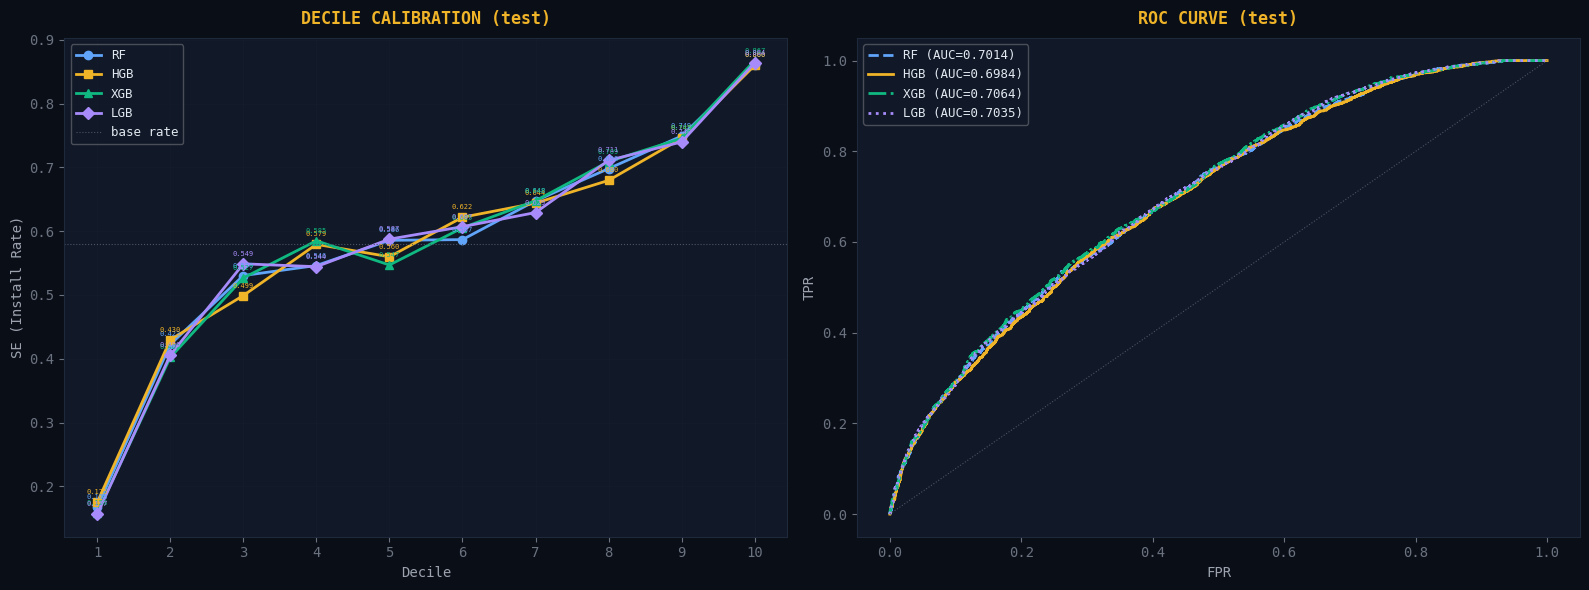

In [67]:
p_rf  = best_rf.predict(X_test)
p_hgb = best_hgb.predict(X_test)
p_xgb = best_xgb.predict(X_test)
p_lgb = best_lgb.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Decile curves ──
ax = axes[0]
for preds, label, color, marker in [
    (p_rf,  "RF",  BLUE,   "o"),
    (p_hgb, "HGB", AMBER,  "s"),
    (p_xgb, "XGB", GREEN,  "^"),
    (p_lgb, "LGB", PURPLE, "D"),
]:
    tbl = _decile_table(y_test.values, preds)
    d = list(range(1, len(tbl) + 1))
    ax.plot(d, tbl["se"].values, f"{marker}-", color=color, linewidth=2,
            markersize=6, label=label)
    for j, se in enumerate(tbl["se"].values):
        ax.annotate(f"{se:.3f}", (j+1, se), fontsize=5, ha="center", va="bottom",
                    xytext=(0, 5), textcoords="offset points", color=color)

ax.axhline(y_test.mean(), color=GRAY, linestyle=":", linewidth=0.8, label="base rate")
ax.set(xlabel="Decile", ylabel="SE (Install Rate)")
ax.set_title("DECILE CALIBRATION (test)", fontsize=12, fontweight="bold", color=AMBER, pad=10)
ax.set_xticks(range(1, 11))
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(alpha=0.2)

# ── ROC ──
ax = axes[1]
for preds, label, color, ls in [
    (p_rf,  "RF",  BLUE,   "--"),
    (p_hgb, "HGB", AMBER,  "-"),
    (p_xgb, "XGB", GREEN,  "-."),
    (p_lgb, "LGB", PURPLE, ":"),
]:
    fpr, tpr, _ = roc_curve(y_test, preds)
    a = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, linestyle=ls,
            label=f"{label} (AUC={a:.4f})")

ax.plot([0, 1], [0, 1], ":", color=GRAY, linewidth=0.8)
ax.set(xlabel="FPR", ylabel="TPR")
ax.set_title("ROC CURVE (test)", fontsize=12, fontweight="bold", color=AMBER, pad=10)
ax.legend(fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.show()

### 10b · Feature Importance (best RF)

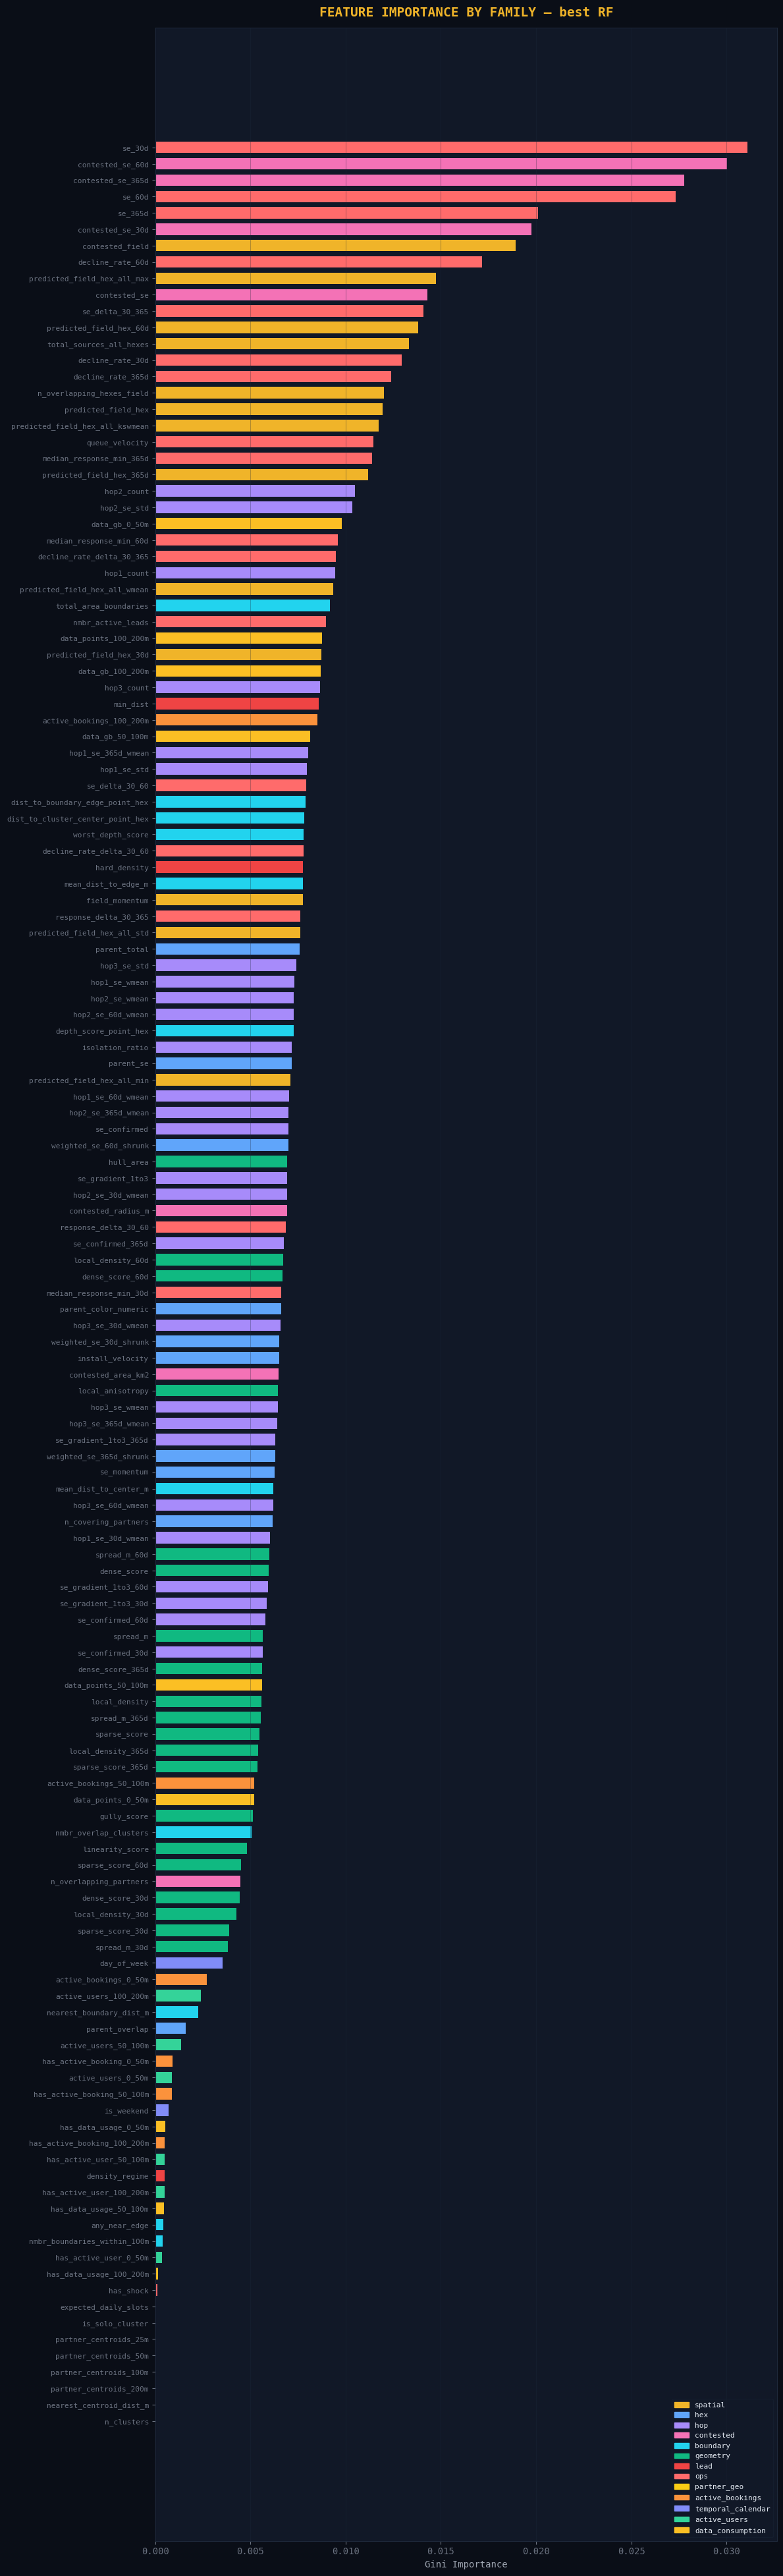

In [68]:
# ── Family → color lookup (derived from registry) ──
FAM_COLORS = {
    "spatial": AMBER, "hex": BLUE, "hop": PURPLE, "contested": PINK,
    "boundary": CYAN, "geometry": GREEN, "lead": RED, "ops": "#ff6b6b",
    "partner_geo": "#facc15",
    "active_bookings": "#fb923c",
    "temporal_calendar": "#818cf8",
    "active_users": "#34d399",
    "data_consumption": "#fbbf24",
}

imp = pd.Series(best_rf.feature_importances_, index=available).sort_values(ascending=True)
colors = [FAM_COLORS.get(family_map.get(f, ""), GRAY) for f in imp.index]

fig, ax = plt.subplots(figsize=(12, max(10, len(imp) * 0.28)))
ax.barh(range(len(imp)), imp.values, color=colors, height=0.7, edgecolor="none")
ax.set_yticks(range(len(imp)))
ax.set_yticklabels(imp.index, fontsize=8)
ax.set_xlabel("Gini Importance")
ax.set_title("FEATURE IMPORTANCE BY FAMILY — best RF",
             fontsize=14, fontweight="bold", color=AMBER, pad=12)
ax.grid(axis="x", alpha=0.3)

patches = [mpatches.Patch(color=c, label=k) for k, c in FAM_COLORS.items()]
ax.legend(handles=patches, loc="lower right", fontsize=8, framealpha=0.3, edgecolor="#1e293b")
plt.tight_layout()
plt.show()


### 10c · Single Tree (depth=4 excerpt)

In [69]:
single_tree = best_rf.estimators_[0]
print(export_text(single_tree, feature_names=available, max_depth=4))

|--- predicted_field_hex_60d <= -0.77
|   |--- data_points_100_200m <= 170.50
|   |   |--- se_30d <= 0.36
|   |   |   |--- dense_score <= 0.09
|   |   |   |   |--- se_confirmed <= 0.11
|   |   |   |   |   |--- truncated branch of depth 7
|   |   |   |   |--- se_confirmed >  0.11
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- dense_score >  0.09
|   |   |   |   |--- hop2_se_30d_wmean <= 0.25
|   |   |   |   |   |--- truncated branch of depth 10
|   |   |   |   |--- hop2_se_30d_wmean >  0.25
|   |   |   |   |   |--- truncated branch of depth 8
|   |   |--- se_30d >  0.36
|   |   |   |--- data_gb_100_200m <= 17059.09
|   |   |   |   |--- predicted_field_hex_all_kswmean <= 0.30
|   |   |   |   |   |--- truncated branch of depth 11
|   |   |   |   |--- predicted_field_hex_all_kswmean >  0.30
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- data_gb_100_200m >  17059.09
|   |   |   |   |--- hop1_se_wmean <= 0.07
|   |   |   |   |   |--- value: [0.33

### 10d · Importance vs Correlation Scatter

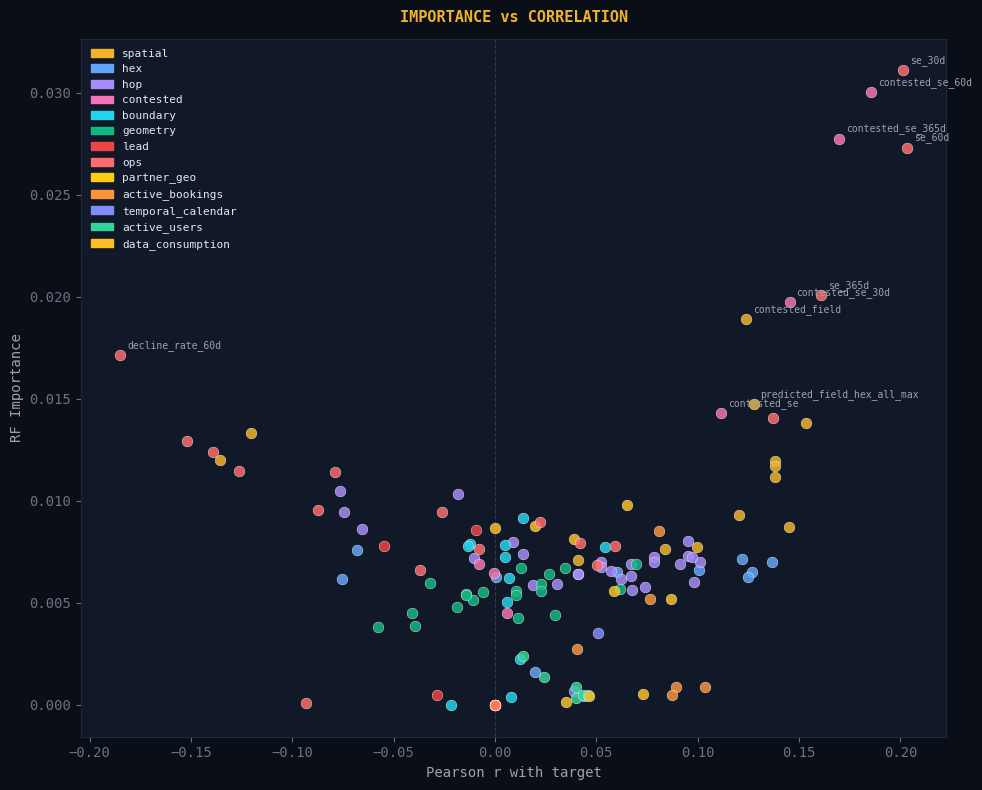

In [70]:
imp_desc = pd.Series(best_rf.feature_importances_, index=available)

fig, ax = plt.subplots(figsize=(10, 8))
for feat in imp_desc.index:
    c = FAM_COLORS.get(family_map.get(feat, ""), GRAY)
    ax.scatter(corr_target.get(feat, 0), imp_desc[feat],
               c=c, s=60, alpha=0.85, edgecolor="white", linewidth=0.3, zorder=3)

for feat in imp_desc.nlargest(10).index:
    if feat in corr_target.index:
        ax.annotate(feat, (corr_target[feat], imp_desc[feat]),
                    fontsize=7, color="#9ca3af", ha="left",
                    xytext=(5, 5), textcoords="offset points")

ax.axvline(0, color=GRAY, linestyle="--", linewidth=0.8, alpha=0.5)
ax.set(xlabel="Pearson r with target", ylabel="RF Importance")
ax.set_title("IMPORTANCE vs CORRELATION", fontsize=11, fontweight="bold", color=AMBER, pad=12)
ax.grid(alpha=0.2)

patches = [mpatches.Patch(color=c, label=k) for k, c in FAM_COLORS.items()]
ax.legend(handles=patches, loc="upper left", fontsize=8, framealpha=0.3, edgecolor="#1e293b")
plt.tight_layout()
plt.show()

## 11 · Comparison with Existing Scores

In [71]:
# Score the full dataset with all best models
df["rf_score"]  = best_rf.predict(df[available].fillna(FILL_VALUE))
df["hgb_score"] = best_hgb.predict(df[available].fillna(FILL_VALUE))
df["xgb_score"] = best_xgb.predict(df[available].fillna(FILL_VALUE))
df["lgb_score"] = best_lgb.predict(df[available].fillna(FILL_VALUE))

COMPARE_COLS = ["rf_score", "hgb_score", "xgb_score", "lgb_score", "composite_score", "spatial_shrunk"]

print(f"{'Score':25s}  {'AUC':>7s}  {'gap_pp':>7s}  {'composite':>10s}  {'mono':>5s}")
print("-" * 62)
for col in COMPARE_COLS:
    if col in df.columns:
        m = score_column(df, col)
        print(f"{col:25s}  {m['auc']:7.4f}  {m['gap_pp']:7.2f}  "
              f"{m['composite']:10.2f}  {str(m['mono']):>5s}")

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:parent_overlap: object